## Exercise 1
1. Understand market dynamics and identify demand drivers.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('fmcg_sales_3years_1M_rows.csv')
df.head(5)

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,...,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,...,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


a) Total sales by country

In [37]:
sales_by_country = df.groupby('country')['gross_sales'].sum().reset_index()
sales_by_country = sales_by_country.set_index('country')

print(sales_by_country.sort_values(by='gross_sales', ascending=False)['gross_sales'].apply(lambda x: f"{x:,.0f}"))

country
Italy          140,628,450
Spain          109,279,741
Germany         90,766,602
Austria         44,018,768
France          43,631,135
Poland          43,535,481
Netherlands     12,888,497
Name: gross_sales, dtype: str


b)Top 20 SKUs by revenue

In [38]:
#Ranking SKUs by revenues (cumulative gross sales)
skus = df.groupby(['sku_id', 'sku_name'])['gross_sales'].sum().reset_index()
skus = skus.set_index('sku_id')
sku_revenues = skus.sort_values(by='gross_sales', ascending=False)

print("Total SKUs:", sku_revenues['sku_name'].count())
print("Top 20 SKUs by revenue:", sku_revenues.head(20)['gross_sales'].sum())
sku_revenues.head(20)

Total SKUs: 102
Top 20 SKUs by revenue: 234445940.63


,sku_name,gross_sales
sku_id,,
SKU0018,BrandF Water,17032424.64
SKU0027,BrandC Chips,16992692.55
SKU0099,BrandC Toothpaste,13865061.24
SKU0026,BrandB Chips,13025419.73
SKU0092,BrandB Soap,12496995.90
SKU0100,BrandD Toothpaste,12351150.68
SKU0064,BrandD Cheese,12326994.00
SKU0061,BrandA Cheese,11967260.40
SKU0028,BrandD Chips,11749108.59


c)Compare ABC classes per region

In [39]:
#ABC Anaysis
A_threshold = 0.80
B_threshold = 0.95

sku_revenues['cumulative_value'] = sku_revenues['gross_sales'].cumsum()
total_value = sku_revenues['gross_sales'].sum()

sku_revenues['cumulative_pct'] = sku_revenues['cumulative_value'] / total_value

# Class assignment
sku_revenues['class'] = 'C'
sku_revenues.loc[sku_revenues['cumulative_pct'] <= A_threshold, 'class'] = 'A'
sku_revenues.loc[
    (sku_revenues['cumulative_pct'] > A_threshold) &
    (sku_revenues['cumulative_pct'] <= B_threshold),
    'class'
] = 'B'

sku_revenues.reset_index(inplace=True)
sku_revenues.to_csv('abc_sku_classification.csv', index=False)

abc_sku = df.merge(sku_revenues[['sku_id', 'class']], on='sku_id', how='left')

summary = abc_sku.groupby(['country', 'class']).agg(
    num_skus=('sku_id', 'nunique'),
    total_value=('gross_sales', 'sum')
).reset_index()

print(summary.pivot_table(index='country', columns='class', values=['num_skus', 'total_value'], aggfunc='sum'))

            num_skus           total_value                         
class              A   B   C             A            B           C
country                                                            
Austria           36  25  19  3.414449e+07   7584771.22  2289508.88
France            39  21  20  3.520376e+07   6090839.26  2336536.61
Germany           47  28  23  7.270568e+07  13856656.06  4204265.01
Italy             49  29  24  1.101940e+08  22946412.42  7488051.50
Netherlands       22  12  11  1.035043e+07   1861343.26   676727.89
Poland            40  22  18  3.474193e+07   6539463.38  2254090.86
Spain             49  29  22  8.739857e+07  16880286.81  5000884.61


d)Identify volatility (XYZ) by SKU

In [52]:
#XYZ Analysis
sku_stats = df.groupby(['sku_id', 'sku_name'])['gross_sales'].agg(mean='mean', std_dev='std').reset_index()
sku_stats['mean'] = sku_stats['mean'].round(2)
sku_stats['std_dev'] = sku_stats['std_dev'].round(2)
sku_stats['cv'] = sku_stats['std_dev'] / sku_stats['mean']
sku_stats['cv'] = sku_stats['cv'].round(2)

x_threshold = 0.20
y_threshold = 0.50

def assign_volatility(cv):
    if cv <= x_threshold:
        return 'X'
    elif cv <= y_threshold and cv > x_threshold:
        return 'Y'
    else:
        return 'Z'

sku_stats['xyz'] = sku_stats['cv'].apply(assign_volatility)
sku_stats.to_csv('sku_xyz_analysis_value.csv', index=False)

e)Correlate price, promotions, and volume

In [41]:
#Find correlation between list_price, units_sold, and promo_flag
correlation_matrix = df[['list_price', 'promo_flag', 'units_sold']].corr()
print(correlation_matrix)

            list_price  promo_flag  units_sold
list_price    1.000000   -0.047780   -0.082791
promo_flag   -0.047780    1.000000    0.295772
units_sold   -0.082791    0.295772    1.000000


f)Visualise seasonality (monthly & weekly patterns)

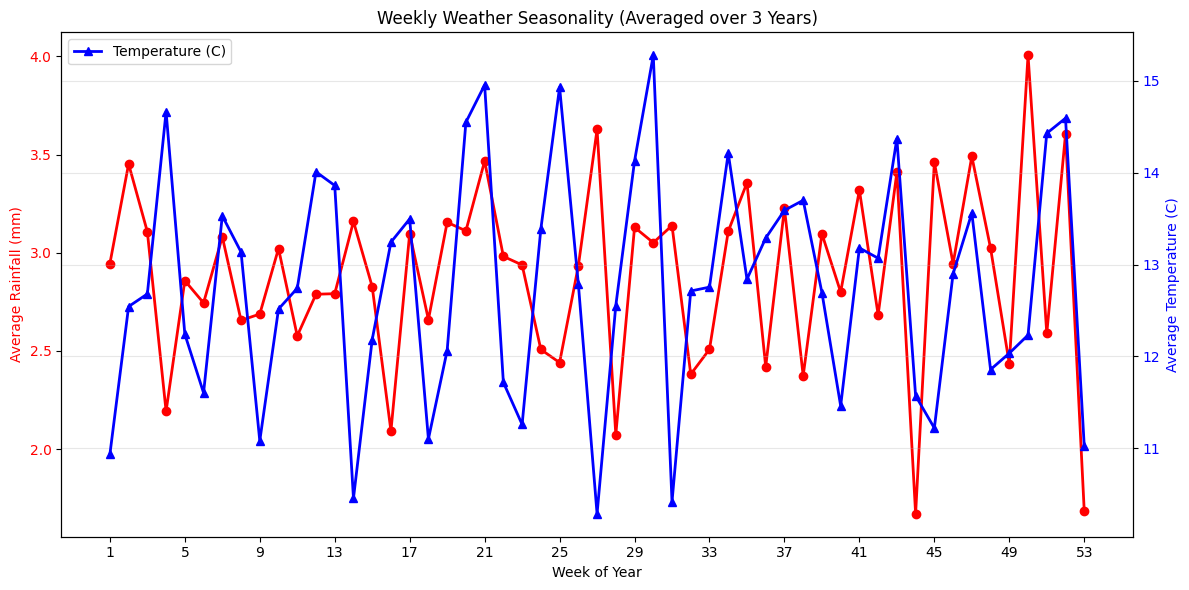

In [42]:
'''Weekly seasonality
Grouping by week and using avg for each week over the 3 years.
'''
weekly_data = df.groupby('weekofyear').agg(
    rain_mm=('rain_mm', 'mean'),
    temperature=('temperature', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(weekly_data['weekofyear'], weekly_data['rain_mm'], label='Rainfall (mm)', color='r', marker='o', linewidth=2)
ax.set_xlabel('Week of Year')
ax.set_ylabel('Average Rainfall (mm)', color='r')
ax.tick_params(axis='y', labelcolor='r')

ax2 = ax.twinx()
ax2.plot(weekly_data['weekofyear'], weekly_data['temperature'], label='Temperature (C)', color='b', marker='^', linewidth=2)
ax2.set_ylabel('Average Temperature (C)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

plt.title('Weekly Weather Seasonality (Averaged over 3 Years)')
plt.xticks(range(1, 54, 4))
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

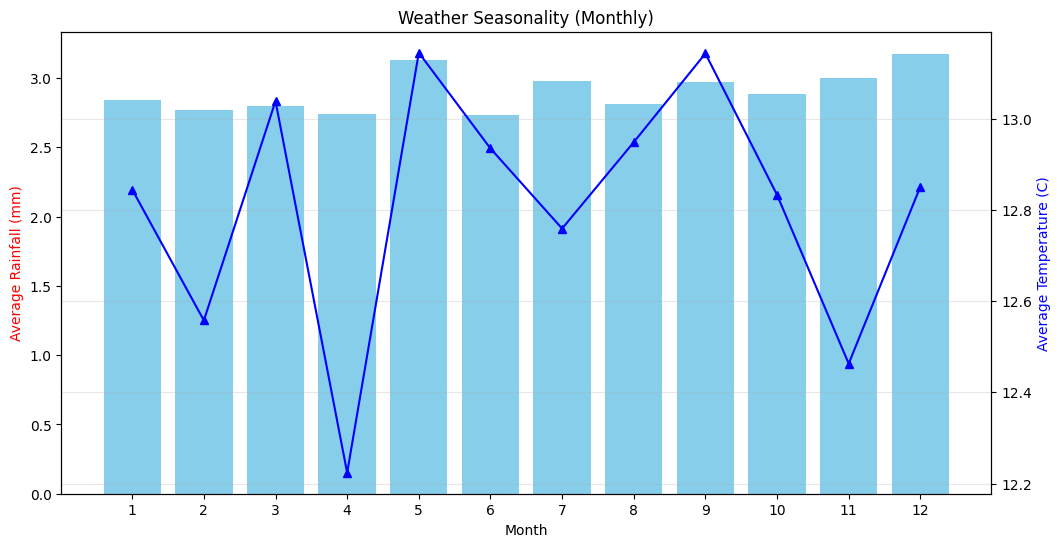

In [43]:
#Seasonality monthly
monthly_data = df.groupby('month').agg(
    rain_mm=('rain_mm', 'mean'),
    temperature=('temperature', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(monthly_data['month'], monthly_data['rain_mm'], label='Rainfall (mm)', color='skyblue')
ax.set_xlabel('Month')
ax.set_ylabel('Average Rainfall (mm)', color='r')

ax2 = ax.twinx()
ax2.plot(monthly_data['month'], monthly_data['temperature'], label='Temperature (C)', color='b', marker='^')
ax2.set_ylabel('Average Temperature (C)', color='b')

plt.xticks(range(1, 13, 1))
plt.title('Weather Seasonality (Monthly)')
plt.grid(True, alpha=0.3)
plt.show()

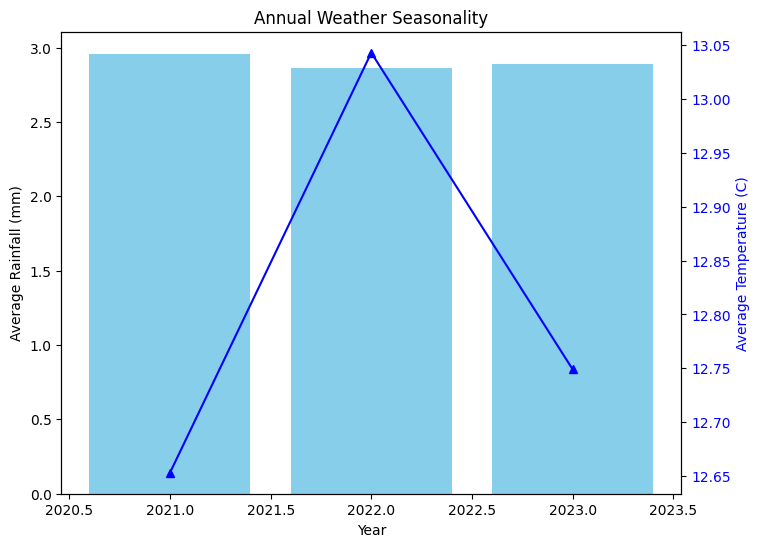

In [44]:
#Seasonality yearly
yearly_data = df.groupby('year').agg(
    rain_mm=('rain_mm', 'mean'),
    temperature=('temperature', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(yearly_data['year'], yearly_data['rain_mm'], label='Rainfall (mm)', color='skyblue')
ax.set_xlabel('Year')
ax.set_ylabel('Average Rainfall (mm)')

ax2 = ax.twinx()
ax2.plot(yearly_data['year'], yearly_data['temperature'], label='Temperature (C)', color='b', marker='^')
ax2.set_ylabel('Average Temperature (C)', color='b')

plt.tick_params(axis='y', labelcolor='b')
plt.title('Annual Weather Seasonality')
plt.xticks(rotation=90)
plt.show()

## Exercise 2: Forecasting
Forecast 10 SKUs with different demand profiles.

Business problem addressed - understocks in A and overstocks in C items

In [45]:
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [46]:
# Merge ABC and XYZ 

abc = pd.read_csv('abc_sku_classification.csv')
xyz = pd.read_csv('sku_xyz_analysis_value.csv') 

segments = abc.merge(
    xyz[['sku_id', 'xyz', 'cv']],
    on='sku_id',
    how='left'
)
segments['segment'] = segments['class'] + segments['xyz']

print(segments['segment'].value_counts().sort_index())


segment
AY    35
AZ    14
BY    20
BZ     9
CY    18
CZ     6
Name: count, dtype: int64


Selecting SKUs to forecast

In [47]:
'''Select 10 SKUs to forecast: 4 AY + 2 AZ + 2 CY + 2 CZ
Reasoning: Solving understocking in A items and overstocking in C items
AY pairs have the highest frequency, so I pick 4 from the classification
'''

selection = [('AY', 4), ('AZ', 2), ('CY', 2), ('CZ', 2)]

selected_skus = []

for seg, n in selection:
    cls, vol = seg[0], seg[1]
    
    subset = (
        segments[
            (segments['class'] == cls) &
            (segments['xyz']   == vol)
        ]
        .sort_values(
            'gross_sales',
            ascending=(cls == 'C')  # C - lowest revenue first
        )
        .drop_duplicates(subset='sku_id')
        .head(n)
    )
    
    selected_skus.append(subset)

# Combine results
selected_skus = (
    pd.concat(selected_skus)
    .reset_index(drop=True)
    [['sku_id', 'sku_name', 'class', 'xyz', 'segment', 'cv', 'gross_sales']]
)

selected_skus.index += 1

display(selected_skus)

,sku_id,sku_name,class,xyz,segment,cv,gross_sales
1,SKU0018,BrandF Water,A,Y,AY,0.42,17032424.64
2,SKU0026,BrandB Chips,A,Y,AY,0.42,13025419.73
3,SKU0092,BrandB Soap,A,Y,AY,0.37,12496995.90
4,SKU0100,BrandD Toothpaste,A,Y,AY,0.38,12351150.68
5,SKU0027,BrandC Chips,A,Z,AZ,0.52,16992692.55
6,SKU0099,BrandC Toothpaste,A,Z,AZ,0.52,13865061.24
7,SKU0050,BrandB Yogurt,C,Y,CY,0.37,255013.60
8,SKU0073,BrandA Softener,C,Y,CY,0.41,447233.74
9,SKU0065,BrandE Cheese,C,Z,CZ,0.52,903620.30
10,SKU0086,BrandB Shampoo,C,Z,CZ,0.52,1128650.57


In [48]:
# Build weekly time series
df['weekofyear_safe'] = df['weekofyear'].clip(upper=52)
'''SOLVED
ValueError: Week 53 does not exist in ISO year 2021 .. You might want to try:
- passing format' if your strings have a consistent format;
- passing `format='IS08601' if your strings are all IS08601 but not necessarily in
exactly the same format;
- passing `format='mixed'`, and the format will be inferred for each element
individually. You might want to use `dayfirst' alongside this. Cell Execution Error'''

df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-W' + df['weekofyear_safe'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u'
)

weekly = (
    df.groupby(['sku_id', 'sku_name', 'date'])
    .agg(
        units_sold  = ('units_sold',  'sum'),
        promo_flag  = ('promo_flag',  'max'),
        temperature = ('temperature', 'mean'),
        rain_mm     = ('rain_mm',     'mean')
    )
    .reset_index()
    .rename(columns={'date': 'ds', 'units_sold': 'y'})
    .sort_values(['sku_id', 'ds'])
)

print(f'Weekly series shape : {weekly.shape}')
weekly.head(5)


Weekly series shape : (15912, 7)


,sku_id,sku_name,ds,y,promo_flag,temperature,rain_mm
0,SKU0001,BrandA Soda,2021-01-04,10619,1,10.625714,3.334286
1,SKU0001,BrandA Soda,2021-01-11,12029,1,10.605714,3.960000
2,SKU0001,BrandA Soda,2021-01-18,9361,1,11.481429,2.474286
3,SKU0001,BrandA Soda,2021-01-25,10924,1,14.477143,2.915714
4,SKU0001,BrandA Soda,2021-02-01,11279,1,10.378571,2.762857


In [49]:
#Backtesting

test_weeks = 13   # 1 quarter hold-out for backtesting

#Helper to build weekly series for each SKU
def get_sku_series(sku_id):
    return (
        weekly[weekly['sku_id'] == sku_id][['ds', 'y']]
        .sort_values('ds')
        .reset_index(drop=True)
    )

#MAPE (Mean Absolute Percentage Error)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

#Backtesting each SKU
backtest_results = []

for _, row in selected_skus.iterrows():
    sku_id   = row['sku_id']
    sku_name = row['sku_name']
    segment  = row['segment']

    data  = get_sku_series(sku_id)
    train = data.iloc[:-test_weeks]
    test  = data.iloc[-test_weeks:]

    m = Prophet(
        interval_width=0.95,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    m.fit(train)

    forecast = m.predict(test[['ds']])
    y_pred   = np.maximum(forecast['yhat'].values, 0)
    y_actual = test['y'].values

    mape_val = round(mape(y_actual, y_pred), 1)
    backtest_results.append({
        'sku_id': sku_id, 'sku_name': sku_name,
        'segment': segment, 'MAPE(%)': mape_val
    })
    print(f'[{segment}] {sku_id} | {sku_name[:30]} - MAPE: {mape_val}%')

# Accuracy summary
accuracy_df = pd.DataFrame(backtest_results).sort_values(['segment', 'MAPE(%)'])
print('\nBacktest Accuracy:')
display(accuracy_df)

20:43:35 - cmdstanpy - INFO - Chain [1] start processing
20:43:35 - cmdstanpy - INFO - Chain [1] done processing


[AY] SKU0018 | BrandF Water - MAPE: 7.2%


20:43:36 - cmdstanpy - INFO - Chain [1] start processing
20:43:36 - cmdstanpy - INFO - Chain [1] done processing


[AY] SKU0026 | BrandB Chips - MAPE: 3.2%


20:43:36 - cmdstanpy - INFO - Chain [1] start processing
20:43:37 - cmdstanpy - INFO - Chain [1] done processing


...

20:43:40 - cmdstanpy - INFO - Chain [1] start processing
20:43:40 - cmdstanpy - INFO - Chain [1] done processing


[CZ] SKU0065 | BrandE Cheese - MAPE: 9.3%


20:43:40 - cmdstanpy - INFO - Chain [1] start processing
20:43:41 - cmdstanpy - INFO - Chain [1] done processing


[CZ] SKU0086 | BrandB Shampoo - MAPE: 15.6%

Backtest Accuracy:


,sku_id,sku_name,segment,MAPE(%)
1,SKU0026,BrandB Chips,AY,3.2
3,SKU0100,BrandD Toothpaste,AY,3.7
2,SKU0092,BrandB Soap,AY,6.5
0,SKU0018,BrandF Water,AY,7.2
4,SKU0027,BrandC Chips,AZ,13.1
5,SKU0099,BrandC Toothpaste,AZ,13.7
6,SKU0050,BrandB Yogurt,CY,4.0
7,SKU0073,BrandA Softener,CY,6.3
8,SKU0065,BrandE Cheese,CZ,9.3
9,SKU0086,BrandB Shampoo,CZ,15.6


20:43:41 - cmdstanpy - INFO - Chain [1] start processing
20:43:41 - cmdstanpy - INFO - Chain [1] done processing
20:43:42 - cmdstanpy - INFO - Chain [1] start processing
20:43:42 - cmdstanpy - INFO - Chain [1] done processing
20:43:43 - cmdstanpy - INFO - Chain [1] start processing
20:43:43 - cmdstanpy - INFO - Chain [1] done processing
20:43:43 - cmdstanpy - INFO - Chain [1] start processing
20:43:43 - cmdstanpy - INFO - Chain [1] done processing
20:43:44 - cmdstanpy - INFO - Chain [1] start processing
20:43:44 - cmdstanpy - INFO - Chain [1] done processing
20:43:45 - cmdstanpy - INFO - Chain [1] start processing
20:43:45 - cmdstanpy - INFO - Chain [1] done processing
20:43:45 - cmdstanpy - INFO - Chain [1] start processing
20:43:45 - cmdstanpy - INFO - Chain [1] done processing
20:43:46 - cmdstanpy - INFO - Chain [1] start processing
20:43:46 - cmdstanpy - INFO - Chain [1] done processing
20:43:47 - cmdstanpy - INFO - Chain [1] start processing
20:43:47 - cmdstanpy - INFO - Chain [1]

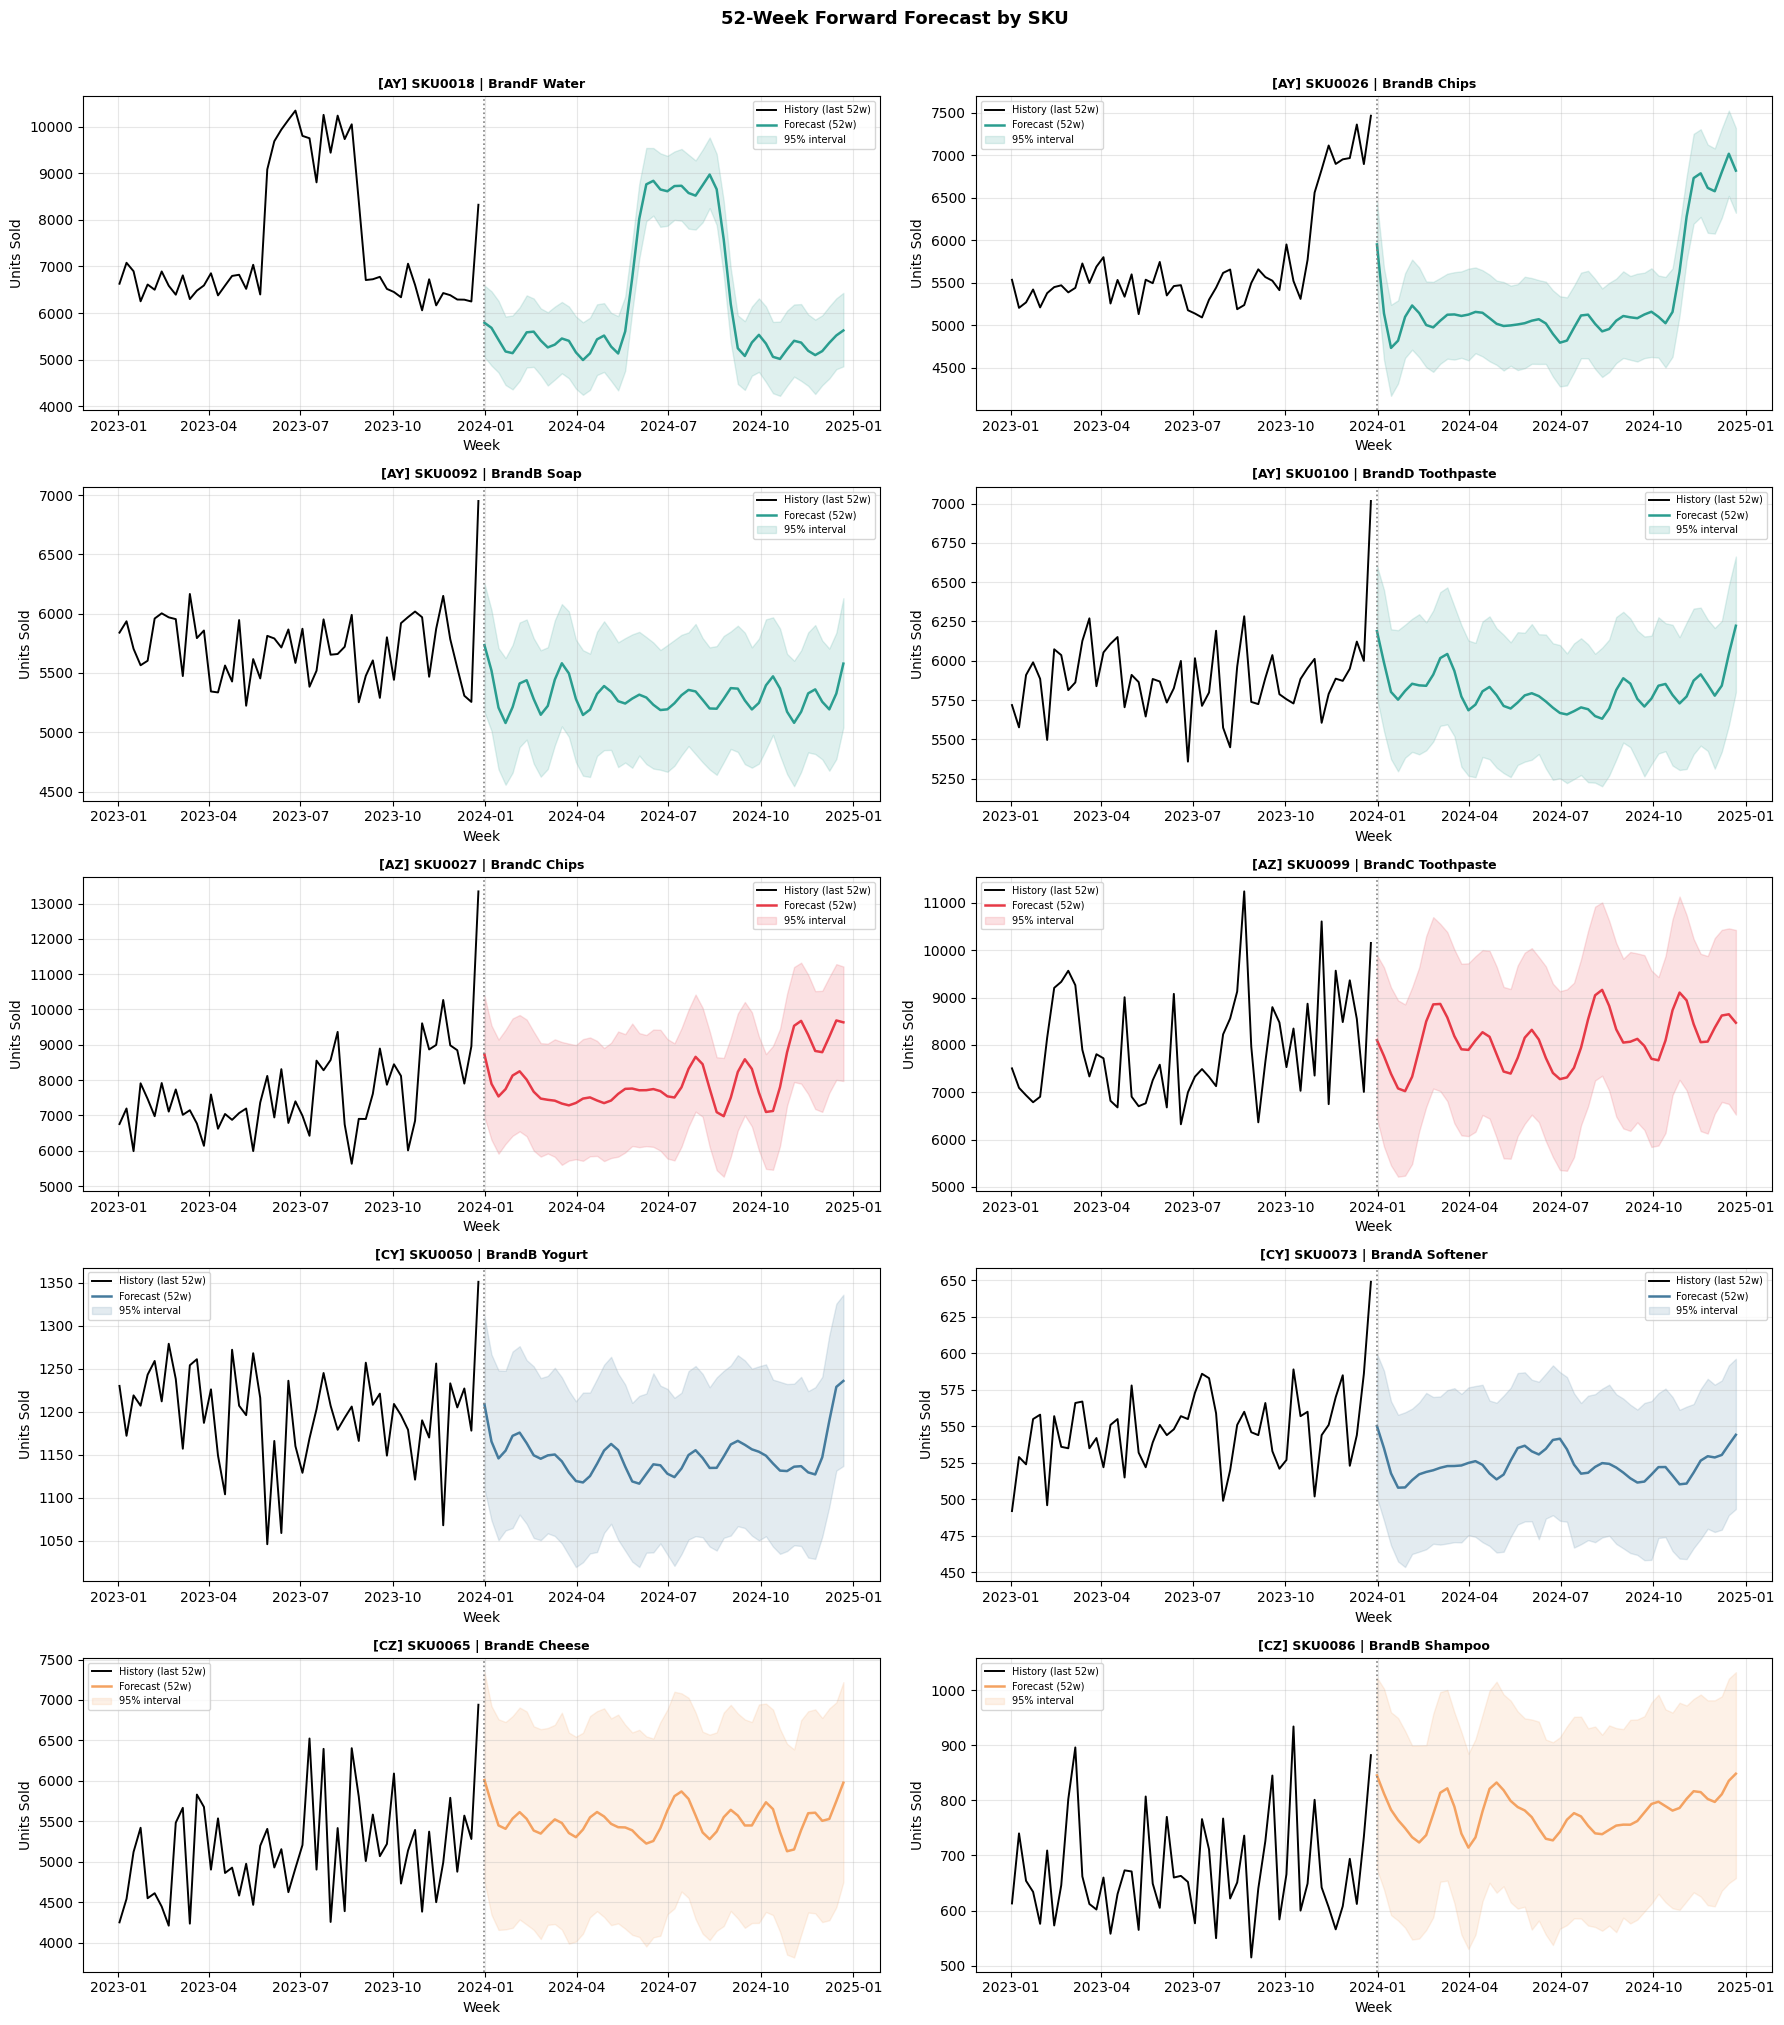


Forecast period : 2021-01-04 - 2024-12-22


In [50]:
#Forward forecast and visualization
fwd_weeks = 52   # full-year forward forecast
segment_colour = {'AY': '#2A9D8F', 'AZ': '#E63946', 'CY': '#457B9D', 'CZ': '#F4A261'}

ncols = 2
nrows = (len(selected_skus) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

fwd_records = []
sku_store = {}

for i, (_, row) in enumerate(selected_skus.iterrows()):
    sku_id   = row['sku_id']
    sku_name = row['sku_name']
    segment  = row['segment']
    col = segment_colour.get(segment, '#888888')

    data = get_sku_series(sku_id)

    m = Prophet(
        interval_width=0.95,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    m.fit(data)

    future   = m.make_future_dataframe(periods=fwd_weeks, freq='W')
    forecast = m.predict(future)
    forecast['yhat']       = np.maximum(forecast['yhat'], 0)
    forecast['yhat_lower'] = np.maximum(forecast['yhat_lower'], 0)

    # Store for later retrieval
    sku_store[sku_id] = {'model': m, 'forecast': forecast, 'sku_name': sku_name, 'segment': segment}

    # Store for export
    fc = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    fc['sku_id'] = sku_id; fc['sku_name'] = sku_name; fc['segment'] = segment
    fwd_records.append(fc)

    # Plot
    ax = axes[i]
    history = data.iloc[-52:]
    future_fc = forecast[forecast['ds'] > data['ds'].max()]

    ax.plot(history['ds'], history['y'],
            color='black', lw=1.4, label='History (last 52w)')
    ax.plot(future_fc['ds'], future_fc['yhat'],
            color=col, lw=1.8, label='Forecast (52w)')
    ax.fill_between(future_fc['ds'],
                    future_fc['yhat_lower'], future_fc['yhat_upper'],
                    alpha=0.15, color=col, label='95% interval')
    ax.axvline(future_fc['ds'].iloc[0], color='grey', ls=':', lw=1.2)
    ax.set_title(f'[{segment}] {sku_id} | {sku_name[:28]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_ylabel('Units Sold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('52-Week Forward Forecast by SKU', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prophet_forward.png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
fwd_df = pd.concat(fwd_records, ignore_index=True)
fwd_df.to_csv('prophet_forecast.csv', index=False)
accuracy_df.to_csv('prophet_accuracy.csv', index=False)

print(f'\nForecast period : {fwd_df.ds.min().date()} - {fwd_df.ds.max().date()}')

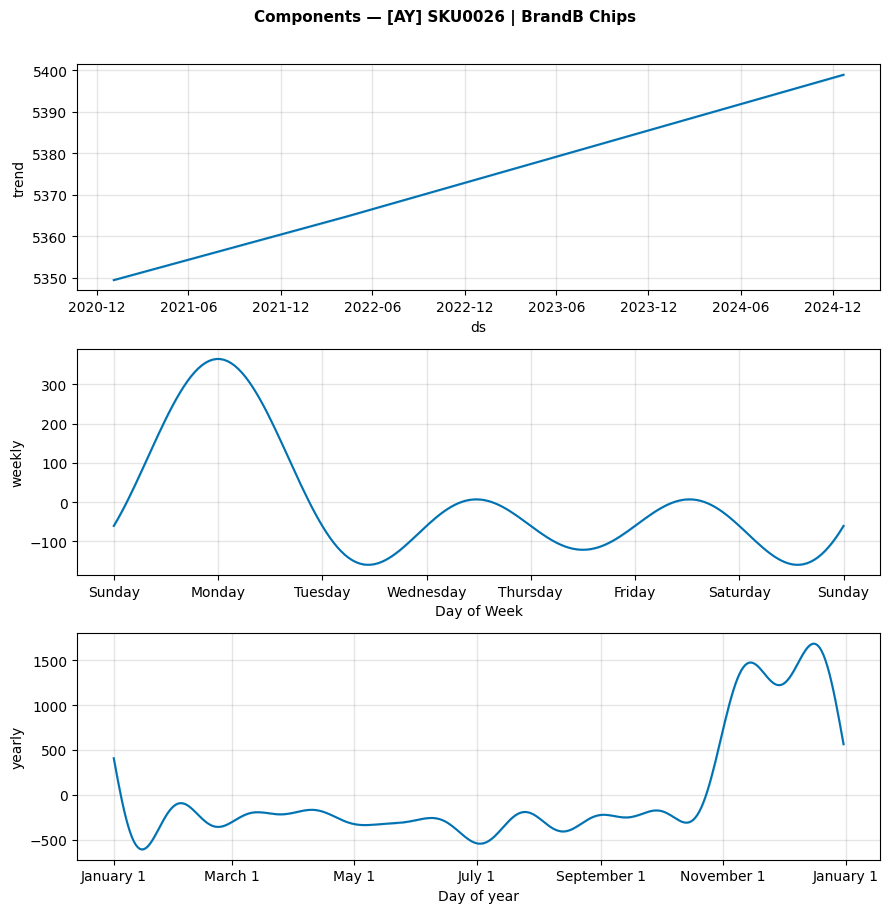

In [53]:
# Select any SKU ID from selected_skus
sku_to_plot = 'SKU0026'

out = sku_store[sku_to_plot]

fig = out['model'].plot_components(out['forecast'])
fig.suptitle(
    f"Components — [{out['segment']}] {sku_to_plot} | {out['sku_name']}",
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()